# BLOOM-560m Baseline: Implicit vs. Literal Meaning

**Purpose:** Replicate Part I's core experiments on BLOOM-560m to establish a baseline for Part II (multilingual code-switching).

**Why BLOOM?** GPT-2's BPE tokenizer fragments Chinese characters into byte-level tokens. BLOOM was trained on 46 languages with proper CJK tokenization.

**Sentence pair:**
- Implicit (request): *"Can you pass the salt?"*
- Literal (ability question): *"Can you lift this rock?"*

**Key Results (from running this notebook):**

| Metric | GPT-2 Small (Part I) | BLOOM-560m |
|--------|---------------------|------------|
| **Pragmatic bottleneck** | Single: L5 | Asymmetric: **L9** (request intent) / **L20** (ability intent) |
| **Cosine sim dip** | ~L6–L8 | **L6–L19** (minimum at L14) |
| **Pattern** | Localized | Two-stage, distributed |
| **Total layers** | 12 | 24 |

**Method note:** Exp 3a (probe-token patching) showed a monotonic ramp because the 5 hand-picked response tokens covered only ~3% of the output distribution. Exp 3b (KL divergence over full vocab) and Exp 3c (per-layer ΔKL) resolved this, revealing true bottleneck layers.

## Setup

In [1]:
import torch
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from transformer_lens import HookedTransformer
import os

torch.set_grad_enabled(False)

model = HookedTransformer.from_pretrained("bloom-560m")
print(f"Model: {model.cfg.model_name}")
print(f"Layers: {model.cfg.n_layers}, Heads: {model.cfg.n_heads}, d_model: {model.cfg.d_model}")

IMPLICIT = "Can you pass the salt?"
LITERAL = "Can you lift this rock?"
PROBE_TOKENS = [" Sure", " Yes", " No", " Of", " I"]

probe_ids = {}
for t in PROBE_TOKENS:
    probe_ids[t] = model.to_single_token(t)
    print(f"  {repr(t):>8} → token id {probe_ids[t]}")

SAVE_DIR = "figures/bloom_baseline"
os.makedirs(SAVE_DIR, exist_ok=True)

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model bloom-560m into HookedTransformer
Model: bloom-560m
Layers: 24, Heads: 16, d_model: 1024
   ' Sure' → token id 142051
    ' Yes' → token id 31830
     ' No' → token id 3928
     ' Of' → token id 23582
      ' I' → token id 473


## Experiment 1: Logit Lens — Probe Token Probabilities

At each layer, project the residual stream (last token) through `ln_final` → `unembed` to get a vocabulary distribution. Track how response token probabilities evolve across layers.

**Caveat:** These 5 probe tokens cover only ~3% of BLOOM's output distribution. Both sentences are dominated by P(" I"), unlike GPT-2 where "Sure" vs "Yes" clearly separated. This reflects BLOOM's different training distribution — it defaults to "I..." responses. See Exp 3b/3c for a distribution-wide analysis.

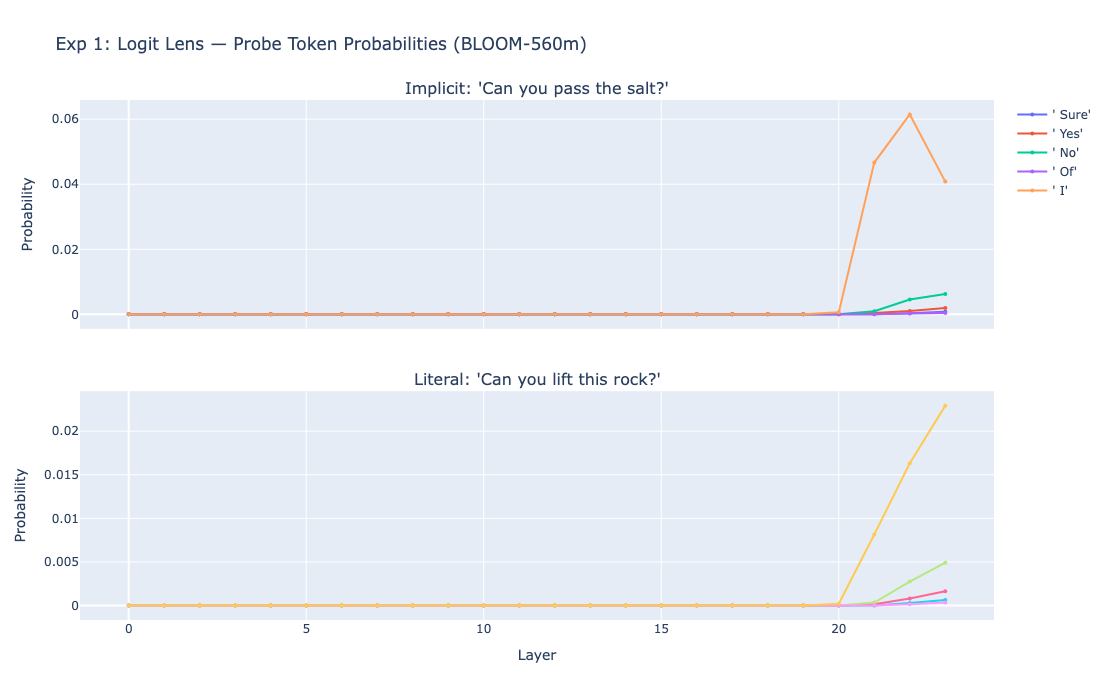


First layer where each probe token leads (among probes only):
  Implicit:
     ' Sure' first leads at layer 0 (p=0.0000)
      ' Yes' first leads at layer 11 (p=0.0000)
       ' No' first leads at layer 13 (p=0.0000)
        ' I' first leads at layer 1 (p=0.0000)
  Literal:
     ' Sure' first leads at layer 0 (p=0.0000)
      ' Yes' first leads at layer 8 (p=0.0000)
       ' No' first leads at layer 11 (p=0.0000)
        ' I' first leads at layer 1 (p=0.0000)


In [2]:
def logit_lens_probe(model, prompt, probe_ids):
    """
    For each layer, project the last-token residual stream into vocab space
    and return probabilities for each probe token.
    Returns dict: {token_str: [prob_layer0, prob_layer1, ...]}
    """
    tokens = model.to_tokens(prompt)
    _, cache = model.run_with_cache(tokens)

    results = {t: [] for t in probe_ids}
    for layer in range(model.cfg.n_layers):
        resid = cache[f"blocks.{layer}.hook_resid_post"][0, -1, :]
        scaled = model.ln_final(resid)
        logits = model.unembed(scaled.unsqueeze(0)).squeeze(0)
        probs = torch.softmax(logits, dim=-1)

        for t, tid in probe_ids.items():
            results[t].append(probs[tid].item())

    return results


probs_implicit = logit_lens_probe(model, IMPLICIT, probe_ids)
probs_literal = logit_lens_probe(model, LITERAL, probe_ids)

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=[f"Implicit: '{IMPLICIT}'", f"Literal: '{LITERAL}'"],
    shared_xaxes=True, vertical_spacing=0.12,
)

layers = list(range(model.cfg.n_layers))
for row, (probs, label) in enumerate(
    [(probs_implicit, "implicit"), (probs_literal, "literal")], 1
):
    for token_str, prob_list in probs.items():
        fig.add_trace(go.Scatter(
            x=layers, y=prob_list,
            mode="lines+markers", name=repr(token_str),
            showlegend=(row == 1), marker=dict(size=4),
        ), row=row, col=1)

fig.update_xaxes(title_text="Layer", row=2, col=1)
fig.update_yaxes(title_text="Probability", row=1, col=1)
fig.update_yaxes(title_text="Probability", row=2, col=1)
fig.update_layout(
    title="Exp 1: Logit Lens — Probe Token Probabilities (BLOOM-560m)",
    height=700, width=900,
)
fig.write_image(f"{SAVE_DIR}/logit_lens_probe.png", scale=2)
fig.show()

print("\nFirst layer where each probe token leads (among probes only):")
for label, probs in [("Implicit", probs_implicit), ("Literal", probs_literal)]:
    print(f"  {label}:")
    for t in PROBE_TOKENS:
        for layer in layers:
            layer_probs = {tok: probs[tok][layer] for tok in PROBE_TOKENS}
            if max(layer_probs, key=layer_probs.get) == t:
                print(f"    {repr(t):>8} first leads at layer {layer} (p={probs[t][layer]:.4f})")
                break

## Experiment 2: Cosine Similarity — Representational Divergence

At each layer, compute cosine similarity between implicit and literal residual streams (last token). The dip reveals where internal representations diverge most.

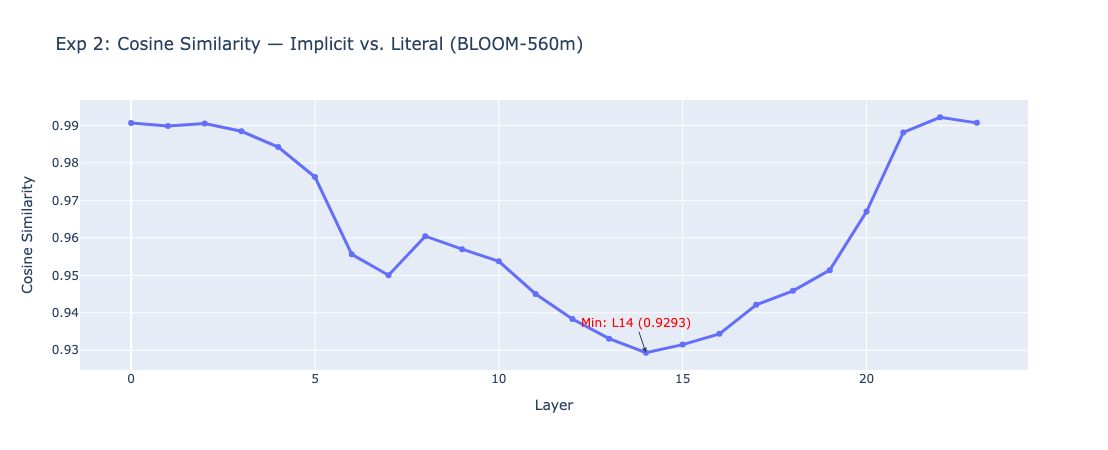

Cosine sim dip range: L6 to L19
Minimum at layer 14: 0.9293


In [3]:
tokens_impl = model.to_tokens(IMPLICIT)
tokens_lit = model.to_tokens(LITERAL)
_, cache_impl = model.run_with_cache(tokens_impl)
_, cache_lit = model.run_with_cache(tokens_lit)

cos_sim_fn = torch.nn.CosineSimilarity(dim=0)
similarities = []

for layer in range(model.cfg.n_layers):
    resid_impl = cache_impl[f"blocks.{layer}.hook_resid_post"][0, -1, :]
    resid_lit = cache_lit[f"blocks.{layer}.hook_resid_post"][0, -1, :]
    sim = cos_sim_fn(resid_impl, resid_lit).item()
    similarities.append(sim)

min_layer = int(np.argmin(similarities))
min_sim = similarities[min_layer]

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=list(range(model.cfg.n_layers)), y=similarities,
    mode="lines+markers", name="Cosine Similarity",
    marker=dict(size=6), line=dict(width=3),
))
fig.add_annotation(
    x=min_layer, y=min_sim,
    text=f"Min: L{min_layer} ({min_sim:.4f})",
    showarrow=True, arrowhead=2, font=dict(size=12, color="red"),
)
fig.update_layout(
    title="Exp 2: Cosine Similarity — Implicit vs. Literal (BLOOM-560m)",
    xaxis_title="Layer", yaxis_title="Cosine Similarity",
    height=450, width=800,
)
fig.write_image(f"{SAVE_DIR}/cosine_similarity.png", scale=2)
fig.show()

threshold = (min_sim + max(similarities)) / 2
dip_layers = [l for l, s in enumerate(similarities) if s < threshold]
if dip_layers:
    print(f"Cosine sim dip range: L{dip_layers[0]} to L{dip_layers[-1]}")
print(f"Minimum at layer {min_layer}: {min_sim:.4f}")

## Experiment 3a: Activation Patching — Probe Tokens (Superseded)

⚠️ **This experiment is kept for reference but its conclusions are misleading.** It measures patching effect using only 5 hand-picked response tokens, which cover ~3% of BLOOM's output distribution. The resulting monotonic ramp is a "closing effect" (later layers have less time to wash out the intervention), not a real bottleneck signal.

**See Exp 3b and 3c below for the corrected analysis using full-distribution KL divergence.**

Unpatched literal probs:
   ' Sure': 0.0006
    ' Yes': 0.0016
     ' No': 0.0049
     ' Of': 0.0003
      ' I': 0.0229

  Total coverage: 0.0305 (only 3.0% of distribution)


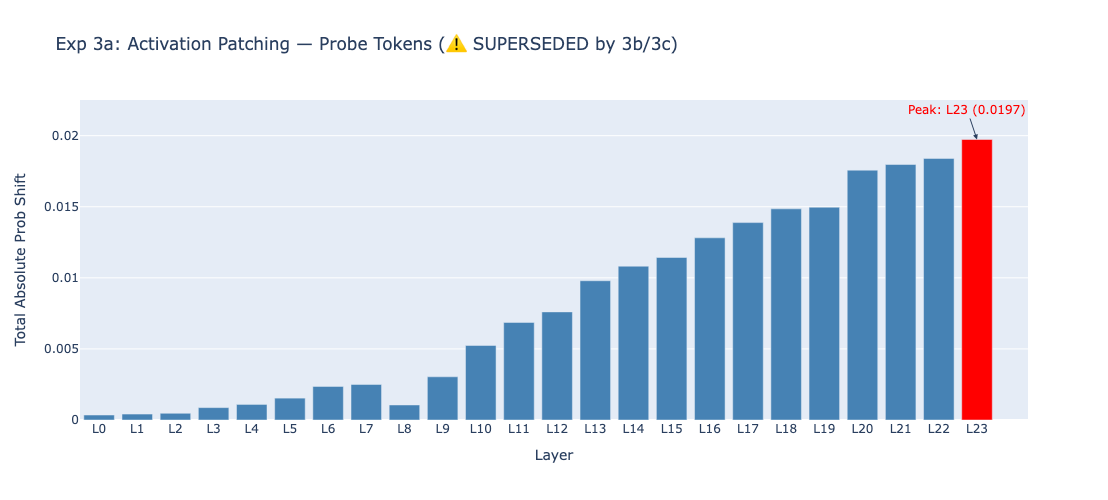


⚠️ Peak at L23 is a closing effect, not a true bottleneck.
See Exp 3b/3c for full-distribution analysis.


In [4]:
# Cache implicit activations (source for patching)
tokens_impl = model.to_tokens(IMPLICIT)
_, cache_impl = model.run_with_cache(tokens_impl)

# Get unpatched literal output (target being patched into)
tokens_lit = model.to_tokens(LITERAL)
lit_logits = model.forward(tokens_lit)
lit_probs = torch.softmax(lit_logits[0, -1, :], dim=-1)

# Baseline response token probs for literal sentence
baseline_probs = {t: lit_probs[tid].item() for t, tid in probe_ids.items()}
print("Unpatched literal probs:")
for t, p in baseline_probs.items():
    print(f"  {repr(t):>8}: {p:.4f}")
print(f"\n  Total coverage: {sum(baseline_probs.values()):.4f} (only {sum(baseline_probs.values())*100:.1f}% of distribution)")

# Patch at each layer and measure effect
patching_effects = []
per_token_effects = {t: [] for t in PROBE_TOKENS}

for layer in range(model.cfg.n_layers):
    src_resid = cache_impl[f"blocks.{layer}.hook_resid_post"][0, -1, :].clone()

    def patch_hook(value, hook, src=src_resid):
        value[0, -1, :] = src
        return value

    patched_logits = model.run_with_hooks(
        tokens_lit,
        fwd_hooks=[(f"blocks.{layer}.hook_resid_post", patch_hook)],
    )
    patched_probs = torch.softmax(patched_logits[0, -1, :], dim=-1)

    total_shift = 0.0
    for t, tid in probe_ids.items():
        shift = patched_probs[tid].item() - baseline_probs[t]
        per_token_effects[t].append(shift)
        total_shift += abs(shift)
    patching_effects.append(total_shift)

peak_layer = int(np.argmax(patching_effects))
peak_effect = patching_effects[peak_layer]

fig = go.Figure()
colors = ["red" if i == peak_layer else "steelblue" for i in range(model.cfg.n_layers)]
fig.add_trace(go.Bar(
    x=[f"L{i}" for i in range(model.cfg.n_layers)],
    y=patching_effects, marker_color=colors,
))
fig.add_annotation(
    x=f"L{peak_layer}", y=peak_effect,
    text=f"Peak: L{peak_layer} ({peak_effect:.4f})",
    showarrow=True, arrowhead=2, font=dict(size=12, color="red"),
)
fig.update_layout(
    title="Exp 3a: Activation Patching — Probe Tokens (⚠️ SUPERSEDED by 3b/3c)",
    xaxis_title="Layer", yaxis_title="Total Absolute Prob Shift",
    height=500, width=900,
)
fig.write_image(f"{SAVE_DIR}/activation_patching_probe.png", scale=2)
fig.show()

print(f"\n⚠️ Peak at L{peak_layer} is a closing effect, not a true bottleneck.")
print("See Exp 3b/3c for full-distribution analysis.")

## Experiment 3b: Activation Patching — KL Divergence (Full Distribution)

Measures the shift in the **entire** output distribution (all ~250k tokens) rather than 5 hand-picked probes. Runs both directions:
- **Impl→Lit:** patch implicit activations into literal run (which layers encode "ability question"?)
- **Lit→Impl:** patch literal activations into implicit run (which layers encode "request intent"?)

**Result:** Both directions show a monotonic ramp — but this is still partially a closing effect. See Exp 3c for the per-layer delta that resolves this.

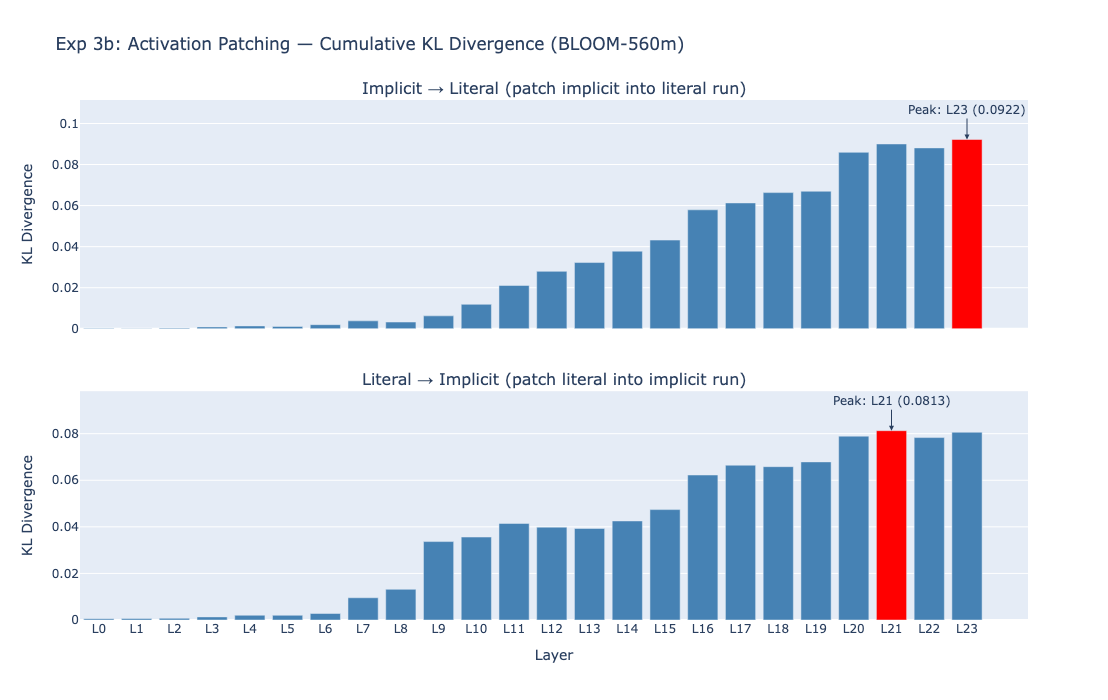

Impl→Lit cumulative peak: Layer 23
Lit→Impl cumulative peak: Layer 21

⚠️ Monotonic ramp — see Exp 3c (delta analysis) to separate closing effect from true bottleneck.


In [5]:
import torch.nn.functional as F

def activation_patching_kl(model, source_prompt, target_prompt):
    """Patch source activations into target run at each layer. Return KL per layer."""
    source_tokens = model.to_tokens(source_prompt)
    _, source_cache = model.run_with_cache(source_tokens)

    target_tokens = model.to_tokens(target_prompt)
    target_logits = model.forward(target_tokens)
    target_probs = torch.softmax(target_logits[0, -1, :], dim=-1)

    kl_per_layer = []
    eps = 1e-10

    for layer in range(model.cfg.n_layers):
        src_resid = source_cache[f"blocks.{layer}.hook_resid_post"][0, -1, :].clone()

        def patch_hook(value, hook, s=src_resid):
            value[0, -1, :] = s
            return value

        patched_logits = model.run_with_hooks(
            target_tokens,
            fwd_hooks=[(f"blocks.{layer}.hook_resid_post", patch_hook)],
        )
        patched_probs = torch.softmax(patched_logits[0, -1, :], dim=-1)

        p = patched_probs + eps
        q = target_probs + eps
        kl = (p * (p.log() - q.log())).sum().item()
        kl_per_layer.append(kl)

    return kl_per_layer


# Run both directions
kl_impl_to_lit = activation_patching_kl(model, IMPLICIT, LITERAL)
kl_lit_to_impl = activation_patching_kl(model, LITERAL, IMPLICIT)

# Plot
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.12,
                    subplot_titles=["Implicit → Literal (patch implicit into literal run)",
                                    "Literal → Implicit (patch literal into implicit run)"])

layers = list(range(model.cfg.n_layers))
layer_labels = [f"L{i}" for i in layers]

for row, (kl_data, direction) in enumerate([
    (kl_impl_to_lit, "Impl→Lit"),
    (kl_lit_to_impl, "Lit→Impl"),
], 1):
    peak_layer = int(np.argmax(kl_data))
    colors = ["red" if i == peak_layer else "steelblue" for i in layers]
    fig.add_trace(go.Bar(
        x=layer_labels, y=kl_data, marker_color=colors,
        showlegend=False,
    ), row=row, col=1)
    fig.add_annotation(
        x=f"L{peak_layer}", y=kl_data[peak_layer],
        text=f"Peak: L{peak_layer} ({kl_data[peak_layer]:.4f})",
        showarrow=True, arrowhead=2, ax=0, ay=-30,
        row=row, col=1,
    )

fig.update_yaxes(title_text="KL Divergence", row=1, col=1)
fig.update_yaxes(title_text="KL Divergence", row=2, col=1)
fig.update_xaxes(title_text="Layer", row=2, col=1)
fig.update_layout(
    title="Exp 3b: Activation Patching — Cumulative KL Divergence (BLOOM-560m)",
    height=700, width=900,
)
fig.write_image(f"{SAVE_DIR}/activation_patching_kl.png", scale=2)
fig.show()

print(f"Impl→Lit cumulative peak: Layer {int(np.argmax(kl_impl_to_lit))}")
print(f"Lit→Impl cumulative peak: Layer {int(np.argmax(kl_lit_to_impl))}")
print("\n⚠️ Monotonic ramp — see Exp 3c (delta analysis) to separate closing effect from true bottleneck.")

## Experiment 3c: Per-Layer ΔKL — The Real Bottleneck Test ⭐

The cumulative KL (Exp 3b) includes a "closing effect" — later layers always show larger effects because there are fewer layers remaining to wash out the intervention.

**ΔKL(l) = KL(l) − KL(l−1)** strips this out. It measures how much **new** pragmatic information each layer writes into the residual stream.

**This is the key result of the baseline notebook.**

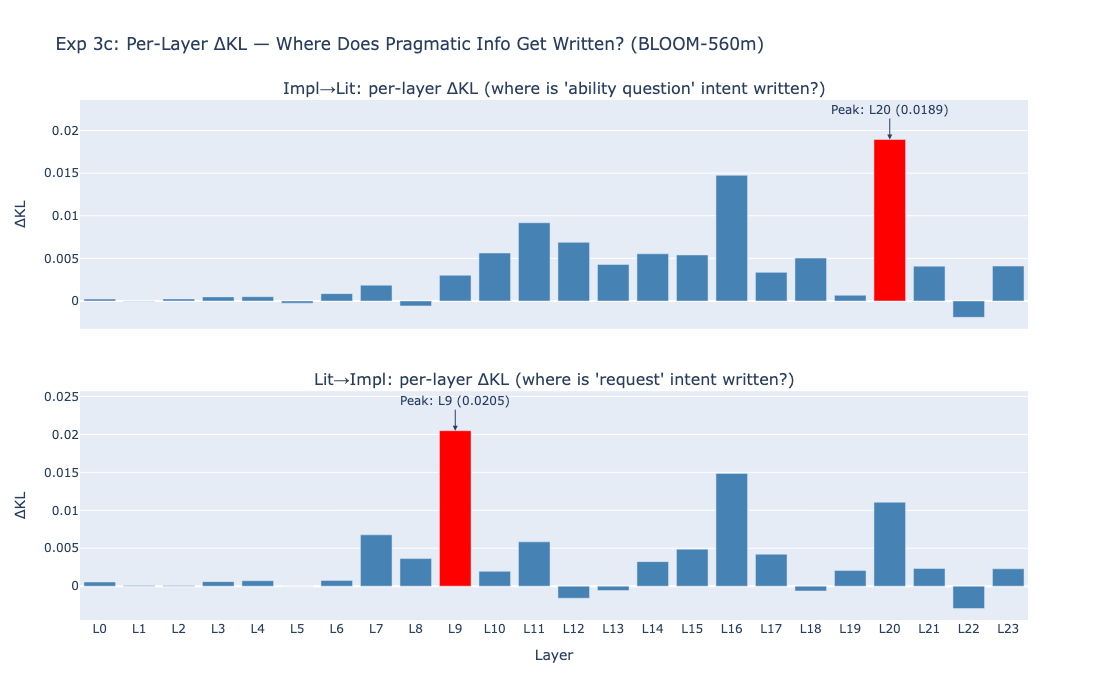

Impl→Lit:  peak ΔKL at L20 (0.0189), median = 0.0032, ratio = 5.95x
Lit→Impl:  peak ΔKL at L9 (0.0205), median = 0.0020, ratio = 10.23x

--- Diagnosis ---
✅ Bottleneck detected: L20 (Impl→Lit) / L9 (Lit→Impl)
   These layers write disproportionately more pragmatic info.
   Asymmetric bottleneck: request intent and ability intent are encoded at different layers.


In [6]:
def compute_deltas(kl_list):
    """Convert cumulative KL to per-layer deltas."""
    return [kl_list[0]] + [kl_list[i] - kl_list[i-1] for i in range(1, len(kl_list))]

deltas_impl = compute_deltas(kl_impl_to_lit)
deltas_lit = compute_deltas(kl_lit_to_impl)

layer_labels = [f"L{i}" for i in range(model.cfg.n_layers)]

fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.12,
    subplot_titles=[
        "Impl→Lit: per-layer ΔKL (where is 'ability question' intent written?)",
        "Lit→Impl: per-layer ΔKL (where is 'request' intent written?)",
    ],
)

for row, (deltas, label) in enumerate([
    (deltas_impl, "Impl→Lit"), 
    (deltas_lit, "Lit→Impl"),
], 1):
    peak_d = int(np.argmax(deltas))
    colors = ["red" if i == peak_d else "steelblue" for i in range(len(deltas))]
    fig.add_trace(go.Bar(
        x=layer_labels, y=deltas, marker_color=colors, showlegend=False,
    ), row=row, col=1)
    fig.add_annotation(
        x=f"L{peak_d}", y=deltas[peak_d],
        text=f"Peak: L{peak_d} ({deltas[peak_d]:.4f})",
        showarrow=True, arrowhead=2, ax=0, ay=-30,
        row=row, col=1,
    )

fig.update_yaxes(title_text="ΔKL", row=1, col=1)
fig.update_yaxes(title_text="ΔKL", row=2, col=1)
fig.update_xaxes(title_text="Layer", row=2, col=1)
fig.update_layout(
    title="Exp 3c: Per-Layer ΔKL — Where Does Pragmatic Info Get Written? (BLOOM-560m)",
    height=700, width=900,
)
fig.write_image(f"{SAVE_DIR}/activation_patching_delta_kl.png", scale=2)
fig.show()

# Diagnosis
peak_d1 = int(np.argmax(deltas_impl))
peak_d2 = int(np.argmax(deltas_lit))
median_d1 = float(np.median(deltas_impl))
median_d2 = float(np.median(deltas_lit))
ratio1 = deltas_impl[peak_d1] / median_d1 if median_d1 > 0 else float('inf')
ratio2 = deltas_lit[peak_d2] / median_d2 if median_d2 > 0 else float('inf')

print(f"Impl→Lit:  peak ΔKL at L{peak_d1} ({deltas_impl[peak_d1]:.4f}), "
      f"median = {median_d1:.4f}, ratio = {ratio1:.2f}x")
print(f"Lit→Impl:  peak ΔKL at L{peak_d2} ({deltas_lit[peak_d2]:.4f}), "
      f"median = {median_d2:.4f}, ratio = {ratio2:.2f}x")

print("\n--- Diagnosis ---")
if ratio1 > 2.0 and ratio2 > 2.0:
    print(f"✅ Bottleneck detected: L{peak_d1} (Impl→Lit) / L{peak_d2} (Lit→Impl)")
    print(f"   These layers write disproportionately more pragmatic info.")
    print(f"   Asymmetric bottleneck: request intent and ability intent are encoded at different layers.")
elif ratio1 > 1.5 or ratio2 > 1.5:
    print(f"⚠️  Weak bottleneck: L{peak_d1} / L{peak_d2}")
else:
    print("❌ No bottleneck — processing is distributed across layers.")

## BLOOM Baseline Summary

### Key Numbers

| Metric | Value |
|--------|-------|
| **Model** | BLOOM-560m (24 layers, 16 heads, d_model=1024) |
| **Cosine sim minimum** | Layer 14 (sim = 0.9293) |
| **Cosine sim dip range** | L6 to L19 |
| **Bottleneck: request intent (Lit→Impl ΔKL)** | **Layer 9** (ratio = 10.23× median) |
| **Bottleneck: ability intent (Impl→Lit ΔKL)** | **Layer 20** (ratio = 5.95× median) |
| **Secondary peak (both directions)** | Layer 16 |

### Comparison with GPT-2 (Part I)

| | GPT-2 Small | BLOOM-560m |
|---|---|---|
| Bottleneck | Single: L5 (42% depth) | Asymmetric: L9 (38%) + L20 (83%) |
| Cosine dip | L6–L8 (narrow) | L6–L19 (wide) |
| Pattern | Localized — one layer does the heavy lifting | Two-stage — request intent (L9) and ability intent (L20) are encoded separately |

### Interpretation

BLOOM's pragmatic processing is **asymmetric and two-stage**, unlike GPT-2's single bottleneck:

1. **Layer 9** is where the model writes "this is a request" into the implicit sentence's residual stream. Replacing this layer with literal-sentence activations causes the largest disruption to the implicit run.

2. **Layer 20** is where the model writes "this is an ability question" into the literal sentence's residual stream. Replacing this layer with implicit-sentence activations causes the largest disruption to the literal run.

3. **Layer 16** shows secondary peaks in both directions — possibly a shared pragmatic processing layer.

4. **Layer 23 has negative ΔKL** — the final layer partially undoes patching effects (self-repair).

### Implications for Part II

The multilingual experiments (Exp 4b in `experiment_multilingual.ipynb`) should test whether L9 and L20 **shift** under code-switched input:
- If peaks stay at L9/L20 → pragmatic circuit is language-agnostic
- If peaks move → circuit is language-dependent
- If peaks disappear → code-switching disrupts pragmatic processing